In [9]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch
from operators.fourier import fftc, ifftc
from visualization.image import plot_image

CONTRASTS = ("flair", "t1", "t1ce", "t2")

def load_case(case, root="../datasets/BraTS/BraTS2021_DataSet",
              contrasts=CONTRASTS, with_seg=False):
    """
    
    Quick-load one BraTS case as raw volumes — no preprocessing.

    case     : case dir name (e.g. "BraTS2021_00000") or a full path to it
    returns  : dict {contrast: np.ndarray of shape (H, W, D)}, + "seg" if requested
    """
    case_dir = case if os.path.isdir(case) else os.path.join(root, case)

    def _load(tag):
        matches = glob.glob(os.path.join(case_dir, f"*_{tag}.nii.gz"))
        if not matches:
            raise FileNotFoundError(f"No '*_{tag}.nii.gz' in {case_dir}")
        return np.asarray(nib.load(matches[0]).get_fdata(), dtype=np.float32)

    out = {c: _load(c) for c in contrasts}
    if with_seg:
        out["seg"] = _load("seg")
    return out

In [3]:
from __future__ import annotations

@torch.no_grad()
def _kmeanspp_init(x, K, gen):
    """k-means++ seeding on (M, D) -> (K, D)."""
    M = x.shape[0]
    centroids = torch.empty(K, x.shape[1], device=x.device, dtype=x.dtype)
    centroids[0] = x[torch.randint(0, M, (1,), generator=gen, device=x.device)]
    closest = torch.cdist(x, centroids[:1]).squeeze(1).pow(2)
    for i in range(1, K):
        probs = closest / closest.sum().clamp(min=1e-12)
        centroids[i] = x[torch.multinomial(probs, 1, generator=gen)]
        closest = torch.minimum(closest, torch.cdist(x, centroids[i:i+1]).squeeze(1).pow(2))
    return centroids


@torch.no_grad()
def minibatch_kmeans(
    x: torch.Tensor,
    n_clusters: int,
    batch_size: int = 1024,
    max_iter: int = 100,
    tol: float = 0.0,
    max_no_improvement: int | None = 10,
    n_init: int = 3,
    init_size: int | None = None,
    reassignment_ratio: float = 0.01,
    seed: int | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    GPU-compatible Mini-Batch K-Means, following sklearn.cluster.MiniBatchKMeans.

    Args mirror the sklearn names. Returns (labels (N,), centroids (K, D)).
    """
    N, D = x.shape
    K = n_clusters
    device, dtype = x.device, x.dtype
    bs = min(batch_size, N)

    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    if init_size is None:
        init_size = 3 * bs if 3 * bs >= K else 3 * K
    init_size = min(init_size, N)

    # --- multiple inits on a random subset, keep best by inertia on a validation subset ---
    valid_idx = torch.randint(0, N, (init_size,), generator=gen, device=device)
    x_valid = x[valid_idx]
    best_centroids, best_inertia = None, None
    for _ in range(n_init):
        sub = x[torch.randint(0, N, (init_size,), generator=gen, device=device)]
        c = _kmeanspp_init(sub, K, gen)
        inertia = torch.cdist(x_valid, c).amin(dim=1).pow(2).sum()
        if best_inertia is None or inertia < best_inertia:
            best_centroids, best_inertia = c, inertia
    centroids = best_centroids

    # --- streaming optimization ---
    counts = torch.zeros(K, device=device, dtype=dtype)      # running weight per center
    n_steps = (max_iter * N) // bs
    ewa = ewa_min = None
    no_improve = 0
    since_reassign = 0
    alpha = min(bs * 2.0 / (N + 1), 1.0)                     # EWA smoothing factor

    for step in range(n_steps):
        idx = torch.randint(0, N, (bs,), generator=gen, device=device)
        batch = x[idx]

        dists = torch.cdist(batch, centroids)                # (bs, K)
        labels = dists.argmin(dim=1)
        batch_inertia = dists.gather(1, labels[:, None]).squeeze(1).pow(2).sum() / bs

        # per-center batch sums and counts
        bcounts = torch.zeros(K, device=device, dtype=dtype)
        bcounts.index_add_(0, labels, torch.ones(bs, device=device, dtype=dtype))
        bsums = torch.zeros(K, D, device=device, dtype=dtype)
        bsums.index_add_(0, labels, batch)

        # incremental-mean update with decaying learning rate eta = 1 / new_count
        old = centroids.clone()
        active = bcounts > 0
        new_counts = counts + bcounts
        eta = torch.where(active, 1.0 / new_counts.clamp(min=1), torch.zeros_like(counts))
        centroids = centroids + eta.unsqueeze(1) * (bsums - bcounts.unsqueeze(1) * centroids)
        counts = new_counts

        # --- periodic reassignment of low-count centers ---
        since_reassign += bs
        if (counts == 0).any() or since_reassign >= 10 * K:
            since_reassign = 0
            to_reassign = counts < reassignment_ratio * counts.max().clamp(min=1)
            n_re = int(to_reassign.sum())
            if 0 < n_re <= bs // 2:
                # pick batch points far from their nearest center (distance-weighted)
                d = torch.cdist(batch, centroids).amin(dim=1).pow(2)
                pick = torch.multinomial(d / d.sum().clamp(min=1e-12), n_re, generator=gen)
                centroids[to_reassign] = batch[pick]
                counts[to_reassign] = 0

        # --- convergence checks (skip first step: it's just init inertia) ---
        if step == 0:
            continue
        if tol > 0.0 and (centroids - old).pow(2).sum() <= tol:
            break
        ewa = batch_inertia if ewa is None else ewa * (1 - alpha) + batch_inertia * alpha
        if ewa_min is None or ewa < ewa_min:
            ewa_min, no_improve = ewa, 0
        else:
            no_improve += 1
        if max_no_improvement is not None and no_improve >= max_no_improvement:
            break

    # final hard assignment over all points (sklearn computes labels_ at the end)
    labels = torch.cdist(x, centroids).argmin(dim=1)
    return labels, centroids

In [4]:
os.chdir('/scratch/ee2178/ImMAP')

In [5]:
data = load_case("BraTS2021_00000")

In [6]:
# Load flair image
flair = data['flair']
t1ce = data['t1ce']
t1 = data['t1']
t2 = data['t2']

x = torch.tensor(np.array([flair, t1, t1ce, t2]))

In [18]:
# Visualizing histograms to see what normalization factor we need

def gen_hist(x):
    # Compute histogram using PyTorch
    counts, edges = np.histogram(x, bins=100)
    
    # Plot using matplotlib bar chart
    plt.bar(edges[:-1], counts, width=np.diff(edges), align='edge', edgecolor='black')
    plt.xlabel('Bins')
    plt.ylabel('Frequency')
    plt.show()

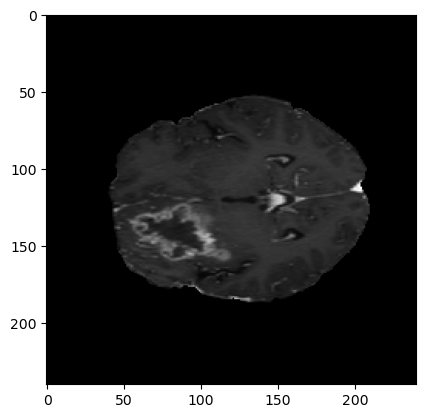

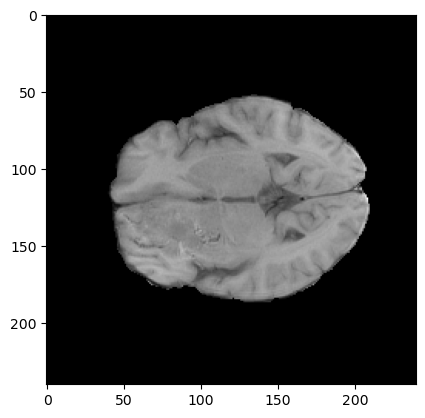

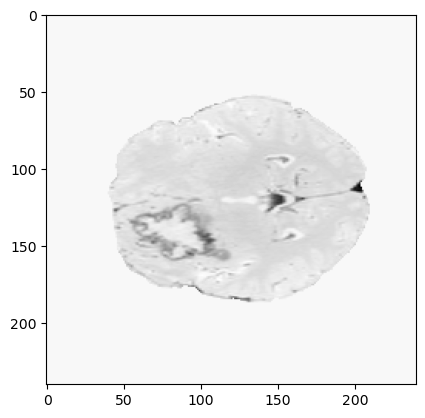

In [34]:
plt.imshow(t1ce[:, :, 70]*mask[:, :, 70].numpy(), cmap = 'gray')
plt.show()
plt.imshow(t1[:, :, 70]*mask[:, :, 70].numpy(), cmap = 'gray')
plt.show()
plt.imshow((t1*mask.numpy()-t1ce*mask.numpy())[:, :, 70], cmap = 'gray')
plt.show()

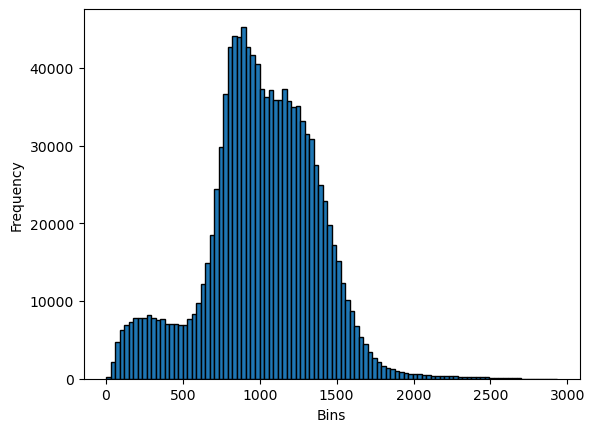

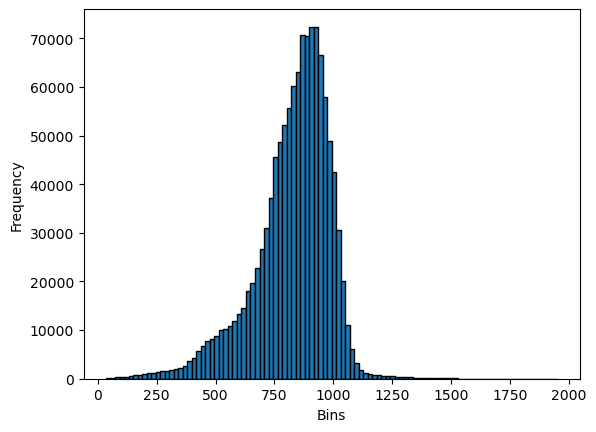

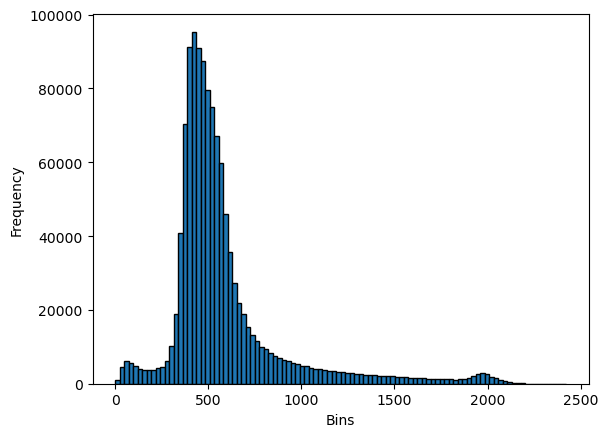

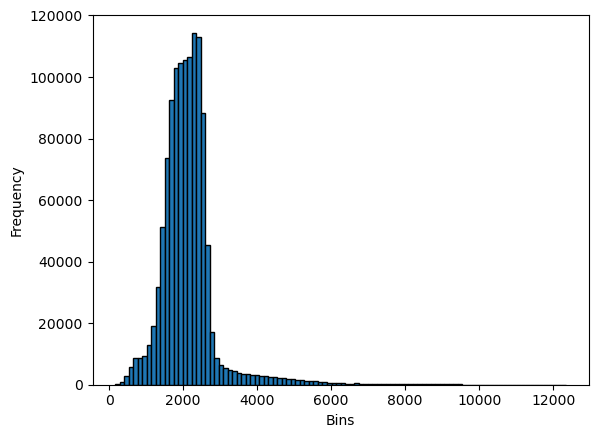

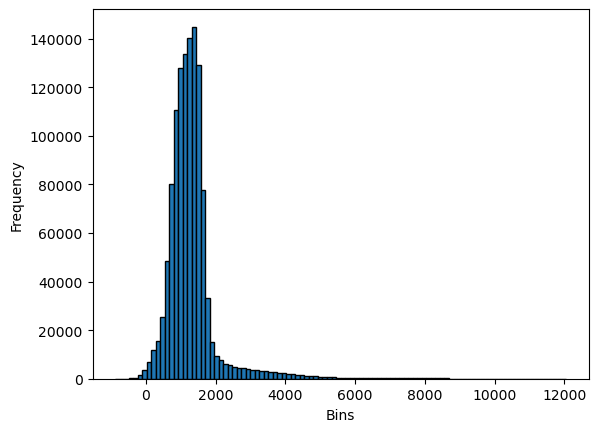

In [39]:
# Generat foreground mask
mask = x.sum(dim = 0) > 0
# Trunacate to slices 40 -120
flair = flair[:, :, 39:120]
t1 = t1[:, :, 39:120]
t1ce = t1ce[:, :, 39:120]
t2 = t2[:, :, 39:120]
mask = mask[:, :, 39:120]

gen_hist(flair[mask])
gen_hist(t1[mask])
gen_hist(t2[mask])
gen_hist(t1ce[mask])

gen_hist((t1ce-t1)[mask])

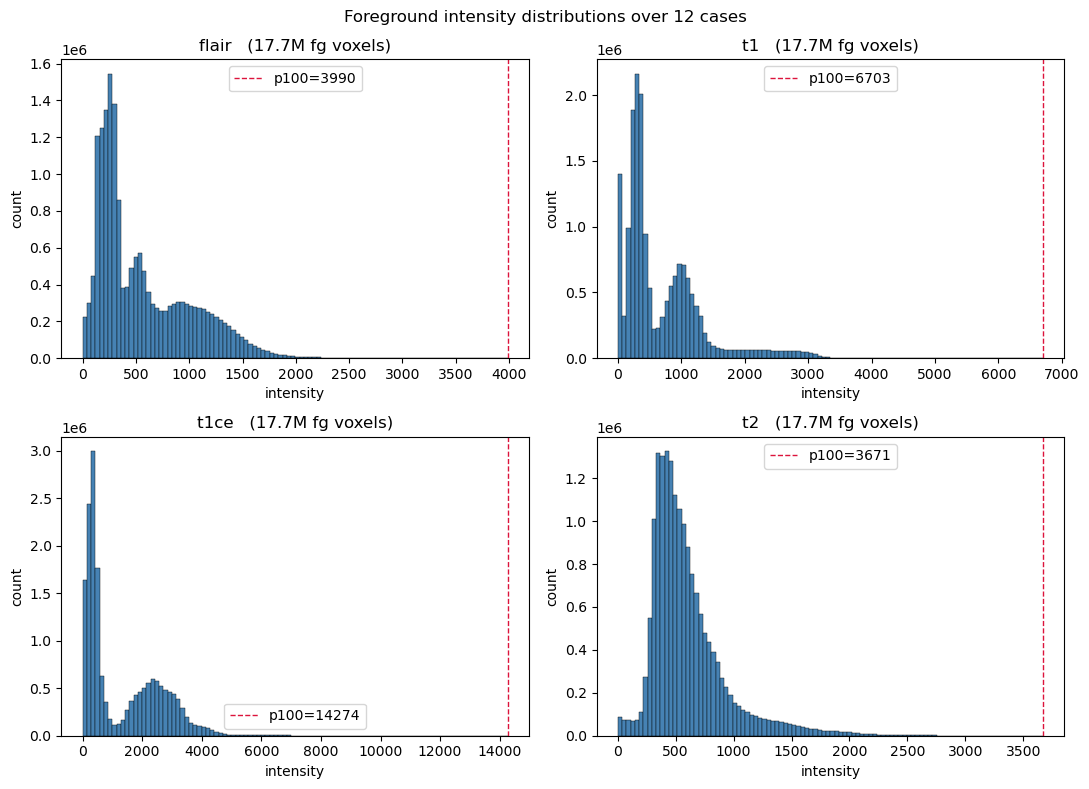

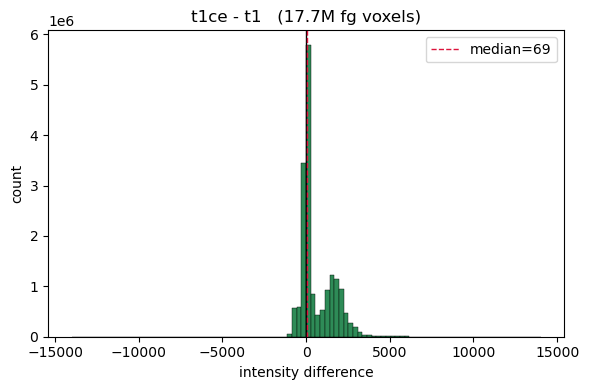

In [44]:
# --- Pooled foreground-intensity histograms over a batch of cases ---
# Extends the single-case check above to many cases so we can eyeball the
# per-contrast intensity distributions (and pick a normalization factor).

def sample_cases(n, root="../datasets/BraTS/BraTS2021_DataSet", seed=0):
    """Random batch of `n` case names discovered under `root`."""
    dirs = sorted(glob.glob(os.path.join(root, "BraTS2021_*")))
    rng  = np.random.default_rng(seed)
    idx  = rng.choice(len(dirs), min(n, len(dirs)), replace=False)
    return [os.path.basename(dirs[i]) for i in idx]


def batch_contrast_hist(cases, contrasts=CONTRASTS, bins=100, clip_pct=100):
    """
    Pool foreground-voxel intensities across `cases`, one histogram per contrast,
    plus the signed enhancement difference t1ce - t1. Foreground = union over
    contrasts (same rule as the single-case cell).

    cases   : iterable of case names/paths for load_case
    returns : dict {contrast: pooled 1-D np.ndarray}, incl. key "t1ce-t1" if available
    """
    pooled = {c: [] for c in contrasts}
    diff   = []                                            # t1ce - t1 on foreground
    for case in cases:
        d   = load_case(case, contrasts=contrasts)
        vol = np.stack([d[c] for c in contrasts])          # (C, H, W, D)
        fg  = vol.sum(0) > 0                                # (H, W, D)  union mask
        for i, c in enumerate(contrasts):
            pooled[c].append(vol[i][fg])                   # (N_fg,)
        if {"t1ce", "t1"} <= set(contrasts):
            diff.append((d["t1ce"] - d["t1"])[fg])         # (N_fg,)
    pooled = {c: np.concatenate(v) for c, v in pooled.items()}

    # per-contrast intensity histograms (>= 0, clipped from 0)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, c in zip(axes.ravel(), contrasts):
        v  = pooled[c]
        hi = np.percentile(v, clip_pct)
        ax.hist(v, bins=bins, range=(0, hi), color="steelblue",
                edgecolor="black", linewidth=0.3)
        ax.axvline(hi, color="crimson", ls="--", lw=1, label=f"p{clip_pct}={hi:.0f}")
        ax.set_title(f"{c}   ({v.size/1e6:.1f}M fg voxels)")
        ax.set_xlabel("intensity"); ax.set_ylabel("count"); ax.legend()
    fig.suptitle(f"Foreground intensity distributions over {len(cases)} cases")
    fig.tight_layout(); plt.show()

    # signed enhancement difference: t1ce - t1 (symmetric range about 0)
    if diff:
        dv     = np.concatenate(diff)
        lo, hi = np.percentile(dv, [100 - clip_pct, clip_pct])
        m      = max(abs(lo), abs(hi))                     # symmetric clip about 0
        med    = np.median(dv)
        plt.figure(figsize=(6, 4))
        plt.hist(dv, bins=bins, range=(-m, m), color="seagreen",
                 edgecolor="black", linewidth=0.3)
        plt.axvline(0,   color="k",       lw=1)
        plt.axvline(med, color="crimson", ls="--", lw=1, label=f"median={med:.0f}")
        plt.title(f"t1ce - t1   ({dv.size/1e6:.1f}M fg voxels)")
        plt.xlabel("intensity difference"); plt.ylabel("count"); plt.legend()
        plt.tight_layout(); plt.show()
        pooled["t1ce-t1"] = dv

    return pooled


cases  = sample_cases(12)
pooled = batch_contrast_hist(cases)
